In [ ]:
import pandas as pd
import numpy as np 

# Travel matrices that came form Dijkstra
tau_pre = pd.read_csv("C://Users//kejsi//OneDrive//Desktop//Master Thesis//Analysis//tau_ij_PRE_expansion.csv")
tau_post = pd.read_csv("C://Users//kejsi//OneDrive//Desktop//Master Thesis/Analysis//tau_ij_post_expansionnew.csv")
print(tau_pre.head())
# Should show: res_id, emp_id, travel_time


   res_id  emp_id   travel_time
0       0      37  24133.055467
1       0      84  13487.421215
2       0      86  14870.020527
3       0      96   7223.367675
4       0      99   9166.240049


In [ ]:
# ========================
#  Residential Centroids
# ========================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geobr import read_census_tract
import matplotlib.pyplot as plt

# 1. Load population data
df_pop = pd.read_excel("C:\\Users\\kejsi\\Downloads\\Base_informacoes_setores2010_sinopse_RJ\\Base_informações_setores2010_sinopse_RJ\\Base_informações_setores2010_sinopse_RJ.xls")
df_pop['Cod_setor'] = df_pop['Cod_setor'].astype(str)

# 2. Load census tract geometries for RJ and filter for Rio de Janeiro city
gdf_sectors = read_census_tract(code_tract=33, year=2010)
gdf_sectors = gdf_sectors[gdf_sectors['code_muni'] == 3304557].to_crs(epsg=4326)
gdf_sectors = gdf_sectors[gdf_sectors.is_valid]  # ensure valid geometries

# 3. Assign ID based on census tract code
gdf_sectors['id'] = gdf_sectors['code_tract'].astype(str)

# 4. Compute metric centroids
gdf_metric = gdf_sectors.to_crs(epsg=31983)  # Project to metric CRS
gdf_metric['centroid_geom'] = gdf_metric.geometry.centroid

# 5. Reproject centroids back to WGS84
gdf_sectors['centroid_geom'] = gdf_metric['centroid_geom'].to_crs(epsg=4326)

# 6. Merge census data with population
gdf_residential = gdf_sectors.merge(df_pop, left_on='id', right_on='Cod_setor', how='left')

# 7. Filter only urban sectors and valid population
gdf_residential['Situacao_setor'] = pd.to_numeric(gdf_residential['Situacao_setor'], errors='coerce')
gdf_residential = gdf_residential[gdf_residential['Situacao_setor'].isin([1, 2, 3])]
gdf_residential = gdf_residential.rename(columns={'V014': 'population'})
gdf_residential = gdf_residential[gdf_residential['population'].notnull()]

# 8. Assign setor_id explicitly (from id = code_tract)
gdf_residential['setor_id'] = gdf_residential['id']

# 9. Create centroid GeoDataFrame
gdf_centroids = gpd.GeoDataFrame(
    gdf_residential[['setor_id', 'population', 'centroid_geom']],
    geometry='centroid_geom',
    crs='EPSG:4326'
)

In [ ]:
# Add an index to gdf_centroids that will match res_id
gdf_centroids = gdf_centroids.reset_index(drop=True)
gdf_centroids['res_id'] = gdf_centroids.index  # create res_id to join on


In [ ]:
# =======================
#  Employment Centroids
# =======================
from google.cloud import bigquery
from google.oauth2 import service_account
import unidecode

# 1. Authenticate BigQuery
key_path = "C:/Users/kejsi/Downloads/rais-455614-d00953360713.json"
credentials = service_account.Credentials.from_service_account_file(key_path)
project_id = "rais-455614"
client = bigquery.Client(credentials=credentials, project=project_id)

# 2. Query RAIS data
query = """
SELECT 
    bairros_rj AS bairro,
    CASE 
        WHEN SAFE_CAST(grau_instrucao_apos_2005 AS INT64) >= 8 THEN 'Alta Qualificacao'
        ELSE 'Baixa Qualificacao'
    END AS nivel_qualificacao,
    AVG(valor_remuneracao_media) AS media_salarial
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE sigla_uf = 'RJ' 
    AND id_municipio = '3304557'
    AND ano = 2011
    AND bairros_rj IS NOT NULL
GROUP BY bairro, nivel_qualificacao

"""

df = client.query(query).to_dataframe()

# 3. Load bairro shapefile
gdf_bairros = gpd.read_file("C:\\Users\\kejsi\\Downloads\\Limite_de_Bairros\\Limite_de_Bairros.shp").to_crs(epsg=4326)

# 4. Load bairro mapping
df_mapping = pd.read_excel("C:\\Users\\kejsi\\Downloads\\bairros_rj.xlsx")
df_mapping = df_mapping.rename(columns={'Nome': 'bairro_name_rais', 'Valor': 'rais_bairro_code'})
df['bairro'] = df['bairro'].astype(str)
df_mapping['rais_bairro_code'] = df_mapping['rais_bairro_code'].astype(str)

# 5. Merge RAIS bairro names
df = df.merge(df_mapping, how='left', left_on='bairro', right_on='rais_bairro_code')

# 6. Clean names
def clean_name(name):
    if pd.isna(name):
        return name
    name = unidecode.unidecode(name).lower().strip()
    for char in ['-', '/', '(', ')']:
        name = name.replace(char, ' ')
    return ' '.join(name.split())

df['bairro_name_rais'] = df['bairro_name_rais'].astype(str)
df['bairro_name_rais_clean'] = df['bairro_name_rais'].apply(clean_name)
gdf_bairros['nome_clean'] = gdf_bairros['nome'].apply(clean_name)

# 7. Manual corrections
manual_name_corrections = {
    'Araujo de Cosmos': 'cosmos',
    'Baia de Guanabara': 'galeao',
    'Nossa Senhora das Gracas': 'penha',
    'Curral Falso': 'guaratiba',
    'Dumas': 'cosmos',
    'Itacolomi': 'ilha de guaratiba',
    'Loteamento Madean': 'campo grande',
    'Tubiacanga': 'cacuia',
    'Dende': 'cacuia',
    'Guarabu': 'cacuia',
    'Freguesia - Ilha do Governador': 'freguesia ilha',
    'Freguesia - Jacarepagua': 'freguesia jacarepagua',
    'Oswaldo Cruz': 'osvaldo cruz',
}
df['bairro_name_rais'] = df['bairro_name_rais'].replace(manual_name_corrections)
df['bairro_name_rais_clean'] = df['bairro_name_rais'].apply(clean_name)

# 8. Merge with spatial data
gdf_employment_full = gdf_bairros.merge(df, how='left', left_on='nome_clean', right_on='bairro_name_rais_clean')

# 9. Project to a metric CRS for accurate centroid calculation
gdf_employment_full_metric = gdf_employment_full.to_crs(epsg=31983)  # UTM zone 23S (SIRGAS 2000)

# 10. Calculate true geometric centroids
gdf_employment_full_metric['centroid'] = gdf_employment_full_metric.geometry.centroid

# 11. Project centroids back to WGS84 (lat/lon)
gdf_centroids_latlon = gdf_employment_full_metric.set_geometry('centroid').to_crs(epsg=4326)

# 12. Extract lat/lon from projected centroids
gdf_employment_full['centroid_lat'] = gdf_centroids_latlon.geometry.y
gdf_employment_full['centroid_lon'] = gdf_centroids_latlon.geometry.x


#  Modified: includes qualification level and average salary
gdf_employment = gdf_employment_full[
    ['bairro_name_rais', 'centroid_lat', 'centroid_lon', 'nivel_qualificacao', 'media_salarial']
].copy()


# 11. Convert to GeoDataFrame
gdf_employment['geometry'] = gdf_employment.apply(lambda row: Point(row['centroid_lon'], row['centroid_lat']), axis=1)
gdf_employment = gpd.GeoDataFrame(gdf_employment, geometry='geometry', crs='EPSG:4326')

In [ ]:
gdf_employment = gdf_employment.reset_index(drop=True)
gdf_employment['emp_id'] = gdf_employment.index


In [ ]:
# Rename columns to distinguish pre/post
tau_pre = tau_pre.rename(columns={'travel_time': 'travel_time_pre'})
tau_post = tau_post.rename(columns={'travel_time': 'travel_time_post'})

# Enrich each tau matrix individually with metadata
# For tau_pre
tau_pre = tau_pre.merge(
    gdf_centroids[['res_id', 'setor_id', 'population']],
    on='res_id', how='left'
)
tau_pre = tau_pre.merge(
    gdf_employment[['emp_id', 'bairro_name_rais', 'nivel_qualificacao', 'media_salarial']],
    on='emp_id', how='left'
)

# For tau_post
tau_post = tau_post.merge(
    gdf_centroids[['res_id', 'setor_id', 'population']],
    on='res_id', how='left'
)
tau_post = tau_post.merge(
    gdf_employment[['emp_id', 'bairro_name_rais', 'nivel_qualificacao', 'media_salarial']],
    on='emp_id', how='left'
)

print(tau_post.columns)
print(tau_pre.columns)

Index(['res_id', 'emp_id', 'travel_time_post', 'setor_id', 'population',
       'bairro_name_rais', 'nivel_qualificacao', 'media_salarial'],
      dtype='object')
Index(['res_id', 'emp_id', 'travel_time_pre', 'setor_id', 'population',
       'bairro_name_rais', 'nivel_qualificacao', 'media_salarial'],
      dtype='object')


In [ ]:
tau_pre['travel_time_pre'] = tau_pre['travel_time_pre'] / 60
tau_post['travel_time_post'] = tau_post['travel_time_post'] / 60


In [ ]:
import numpy as np

kappa = 0.01

# Apply the exponential function
tau_pre['commuting_cost_pre'] = np.exp(kappa * tau_pre['travel_time_pre'])
tau_post['commuting_cost_post'] = np.exp(kappa * tau_post['travel_time_post'])


In [ ]:
# Parameters from paper or estimation
theta = {
    'Alta Qualificacao': 3.3,  # high skill
    'Baixa Qualificacao': 2.7 # low skill
}

# For pre-BRT
tau_pre['cma_component'] = (tau_pre['media_salarial'] / tau_pre['commuting_cost_pre']) ** tau_pre['nivel_qualificacao'].map(theta)

# Now aggregate CMA per res_id and skill group
cma_pre = tau_pre.groupby(['res_id', 'nivel_qualificacao'])['cma_component'].sum().reset_index()
cma_pre = cma_pre.rename(columns={'cma_component': 'CMA_pre'})

#Post BRT
tau_post['cma_component'] = (tau_post['media_salarial'] / tau_post['commuting_cost_post']) ** tau_post['nivel_qualificacao'].map(theta)

cma_post = tau_post.groupby(['res_id', 'nivel_qualificacao'])['cma_component'].sum().reset_index()
cma_post = cma_post.rename(columns={'cma_component': 'CMA_post'})

# merge and log differences
# Merge both CMAs
cma_all = cma_pre.merge(cma_post, on=['res_id', 'nivel_qualificacao'], how='inner')

# Compute log-difference
cma_all['log_CMA_change'] = np.log(cma_all['CMA_post']) - np.log(cma_all['CMA_pre'])


In [ ]:
# Get unique mapping from res_id to setor_id
res_to_setor = tau_pre[['res_id', 'setor_id']].drop_duplicates()

# Merge setor_id into cma_all
cma_all_graph = cma_all.merge(res_to_setor, on='res_id', how='left')

print(cma_all_graph.head())

   res_id  nivel_qualificacao       CMA_pre      CMA_post  log_CMA_change  \
0       0   Alta Qualificacao  5.983674e+11  1.089484e+13        2.901840   
1       0  Baixa Qualificacao  2.008618e+07  6.399632e+09        5.763964   
2       4   Alta Qualificacao  1.349799e+12  1.394699e+12        0.032723   
3       5   Alta Qualificacao  1.349799e+12  1.394699e+12        0.032723   
4       9   Alta Qualificacao  1.349799e+12  1.394699e+12        0.032723   

          setor_id  
0  330455705080006  
1  330455705080006  
2  330455705080010  
3  330455705080011  
4  330455705090055  


In [ ]:
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors



In [ ]:
# Load BRT shapefile
brt_routes = gpd.read_file(r"C:\Users\kejsi\Downloads\Trajetos_BRT\Trajetos_BRT.shp")
# Match CRS if different
if brt_routes.crs != gdf_sectors.crs:
    brt_routes = brt_routes.to_crs(gdf_sectors.crs)

# Filter only the desired BRT corridors
    brt_selected = brt_routes[brt_routes['nome'].isin(['Transoeste', 'Transcarioca', 'Transolímpica'])]



In [ ]:
# Load the Metro shapefile
metro_routes = gpd.read_file(r"C:\Users\kejsi\Downloads\Trajetos_Metr%C3%B4 (1)\Trajetos_Metrô.shp")

# Display column names and unique values in each to help identify Linha 4
print(metro_routes.columns)
for col in metro_routes.columns:
    print(f"{col}: {metro_routes[col].unique()}")


Index(['objectid', 'tipo', 'codlinmetr', 'flg_ativa', 'status', 'data_inc',
       'st_lengths', 'geometry'],
      dtype='object')
objectid: [ 1  2  3  4 78]
tipo: ['Linha 2' 'Linha 1' 'Linha 4' '56' '5']
codlinmetr: [ 2.  1.  4. nan]
flg_ativa: [nan  1.]
status: [None]
data_inc: [None]
st_lengths: [31438.05117801 17377.67216243 12129.15035059            nan]
geometry: <GeometryArray>
[<MULTILINESTRING ((667822.317 7476957.304, 667974.646 7476819.617, 668011.02...>,
 <MULTILINESTRING ((680509.179 7462966.934, 681279.611 7463797.957, 682140.81...>,
 <LINESTRING (684798.012 7457030.867, 684399.842 7457085.4, 683807.957 745714...>,
 <LINESTRING (686914.163 7465579.047, 686914.163 7465579.047, 684698.98 74609...>,
 <LINESTRING (673107.045 7454730.679, 673107.045 7454730.679, 672411.902 7454...>]
Length: 5, dtype: geometry


In [ ]:
# Split CMA by skill level
cma_high = cma_all_graph[cma_all['nivel_qualificacao'] == 'Alta Qualificacao'].copy()
cma_low = cma_all_graph[cma_all['nivel_qualificacao'] == 'Baixa Qualificacao'].copy()


In [ ]:
print(cma_high.columns)


Index(['res_id', 'nivel_qualificacao', 'CMA_pre', 'CMA_post',
       'log_CMA_change'],
      dtype='object')


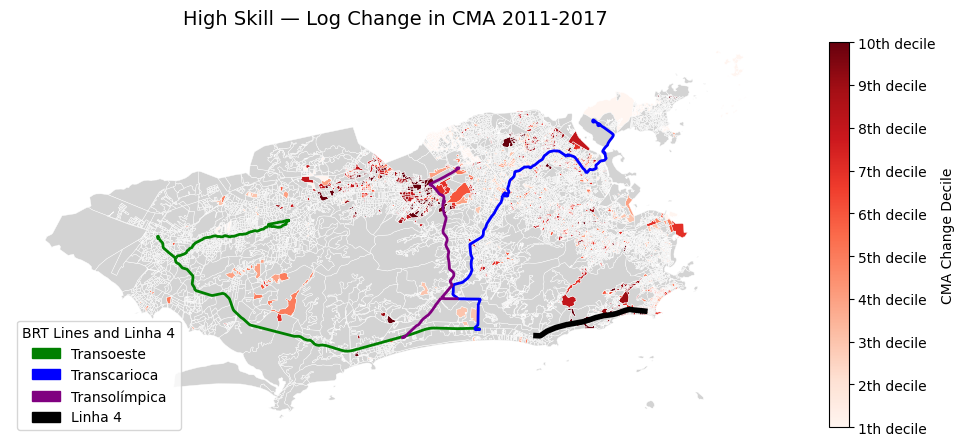

In [ ]:
# Merge and create decile bins
gdf_high = gdf_sectors.merge(cma_high, left_on='code_tract', right_on='setor_id', how='left')
gdf_high['decile'] = pd.qcut(gdf_high['log_CMA_change'], 10, labels=False, duplicates='drop')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_high.plot(
    column='decile',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    ax=ax,
    legend_kwds={
        'label': 'CMA Change Decile',
        'orientation': 'vertical',
        'shrink': 0.5,
        'ticks': range(10),
        'format': FuncFormatter(lambda x, _: f'{int(x)+1}th decile' if x < 10 else '')

    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data"
    }
)
ax.set_title("High Skill — Log Change in CMA 2011-2017", fontsize=14)
ax.axis('off')
plt.tight_layout()
# Assign specific colors to each BRT line
brt_colors = {
    'Transoeste': 'green',
    'Transcarioca': 'blue',
    'Transolímpica': 'purple'
}
brt_lines = ['Transoeste', 'Transcarioca', 'Transolímpica']


# Plot BRT lines with unique colors
for line in brt_lines:
    brt_selected[brt_selected['nome'] == line].plot(
        ax=ax,
        color=brt_colors[line],
        linewidth=2,
        label=line,
        zorder=3
    )

# Load Metro shapefile and filter only Linha 4
metro_routes = gpd.read_file(r"C:\Users\kejsi\Downloads\Trajetos_Metr%C3%B4 (1)\Trajetos_Metrô.shp")
if metro_routes.crs != gdf_sectors.crs:
    metro_routes = metro_routes.to_crs(gdf_sectors.crs)
linha4 = metro_routes[metro_routes['codlinmetr'] == 4]

# Plot Linha 4 in yellow and add to legend
linha4.plot(
    ax=ax,
    color='black',
    linewidth=4,
    label='Linha 4',
    zorder=3
)

# Create manual legend for BRT lines
brt_patches = [
    mpatches.Patch(color=brt_colors[line], label=line) for line in brt_lines
] + [mpatches.Patch(color='black', label='Linha 4')]

#  This line adds the legend to the plot
ax.legend(handles=brt_patches, title="BRT Lines and Linha 4", loc='lower left')

plt.show()



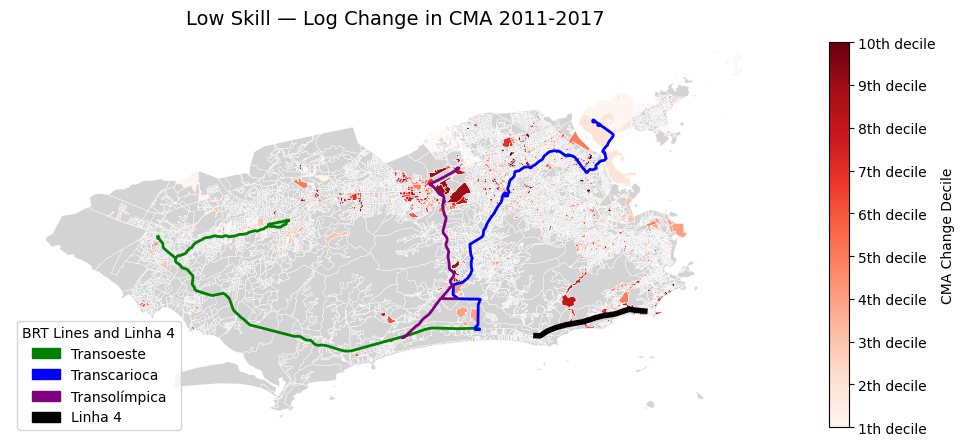

In [ ]:
# Merge and create decile bins
gdf_low = gdf_sectors.merge(cma_low, left_on='code_tract', right_on='setor_id', how='left')
gdf_low['decile'] = pd.qcut(gdf_low['log_CMA_change'], 10, labels=False, duplicates='drop')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_low.plot(
    column='decile',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    ax=ax,
    legend_kwds={
        'label': 'CMA Change Decile',
        'orientation': 'vertical',
        'shrink': 0.5,
        'ticks': range(10),
        'format': FuncFormatter(lambda x, _: f'{int(x)+1}th decile' if x < 10 else '')
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data"
    }
)
ax.set_title("Low Skill — Log Change in CMA 2011-2017", fontsize=14)
ax.axis('off')
plt.tight_layout()
# Assign specific colors to each BRT line
brt_colors = {
    'Transoeste': 'green',
    'Transcarioca': 'blue',
    'Transolímpica': 'purple'
}
brt_lines = ['Transoeste', 'Transcarioca', 'Transolímpica']


# Plot BRT lines with unique colors
for line in brt_lines:
    brt_selected[brt_selected['nome'] == line].plot(
        ax=ax,
        color=brt_colors[line],
        linewidth=2,
        label=line,
        zorder=3
    )

# Load Metro shapefile and filter only Linha 4
metro_routes = gpd.read_file(r"C:\Users\kejsi\Downloads\Trajetos_Metr%C3%B4 (1)\Trajetos_Metrô.shp")
if metro_routes.crs != gdf_sectors.crs:
    metro_routes = metro_routes.to_crs(gdf_sectors.crs)
linha4 = metro_routes[metro_routes['codlinmetr'] == 4]

# Plot Linha 4 in yellow and add to legend
linha4.plot(
    ax=ax,
    color='black',
    linewidth=4,
    label='Linha 4',
    zorder=3
)


# Create manual legend for BRT lines
brt_patches = [
    mpatches.Patch(color=brt_colors[line], label=line) for line in brt_lines
] + [mpatches.Patch(color='black', label='Linha 4')]

ax.legend(handles=brt_patches, title="BRT Lines and Linha 4", loc='lower left')

plt.show()
